# **CHAPTER 15 Processing Sequences Using RNNs and CNNs**  

## Forecasting Horizon: **1 Hour (4 × 15-min)**

#### **sequence-to-sequence**

#### **sequence-to-vector**

#### **vector-to-sequence**

#### **encoder–decoder**

In [3]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorboard
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers
from sklearn.datasets import load_sample_image
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_olivetti_faces
from google.colab import drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


## **ElectricityLoadDiagrams20112014 Dataset**  -->  **UCI**

In [5]:
df = pd.read_csv("/content/drive/MyDrive/LD2011_2014.txt", sep=";", parse_dates=[0])

print(df.head())
print(df.shape)
print(df.columns[:10])
print(df.dtypes[:10])

/tmp/ipykernel_2483/697275784.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,160,164,165,167,170,173,177,178,179,181,184,185,186,223,224,255,280,289,305,308,322,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/LD2011_2014.txt", sep=";", parse_dates=[0])


           Unnamed: 0 MT_001 MT_002 MT_003 MT_004 MT_005 MT_006 MT_007 MT_008  \
0 2011-01-01 00:15:00      0      0      0      0      0      0      0      0   
1 2011-01-01 00:30:00      0      0      0      0      0      0      0      0   
2 2011-01-01 00:45:00      0      0      0      0      0      0      0      0   
3 2011-01-01 01:00:00      0      0      0      0      0      0      0      0   
4 2011-01-01 01:15:00      0      0      0      0      0      0      0      0   

  MT_009  ... MT_361 MT_362 MT_363 MT_364 MT_365 MT_366 MT_367 MT_368 MT_369  \
0      0  ...      0    0.0      0      0      0      0      0      0      0   
1      0  ...      0    0.0      0      0      0      0      0      0      0   
2      0  ...      0    0.0      0      0      0      0      0      0      0   
3      0  ...      0    0.0      0      0      0      0      0      0      0   
4      0  ...      0    0.0      0      0      0      0      0      0      0   

  MT_370  
0      0  
1      0  

In [6]:
df = df.rename(columns={"Unnamed: 0": "timestamp"})

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
print(df.head(5))

(140256, 371)
            timestamp MT_001 MT_002 MT_003 MT_004 MT_005 MT_006 MT_007 MT_008  \
0 2011-01-01 00:15:00      0      0      0      0      0      0      0      0   
1 2011-01-01 00:30:00      0      0      0      0      0      0      0      0   
2 2011-01-01 00:45:00      0      0      0      0      0      0      0      0   
3 2011-01-01 01:00:00      0      0      0      0      0      0      0      0   
4 2011-01-01 01:15:00      0      0      0      0      0      0      0      0   

  MT_009  ... MT_361 MT_362 MT_363 MT_364 MT_365 MT_366 MT_367 MT_368 MT_369  \
0      0  ...      0    0.0      0      0      0      0      0      0      0   
1      0  ...      0    0.0      0      0      0      0      0      0      0   
2      0  ...      0    0.0      0      0      0      0      0      0      0   
3      0  ...      0    0.0      0      0      0      0      0      0      0   
4      0  ...      0    0.0      0      0      0      0      0      0      0   

  MT_370  
0      

In [7]:
print(df.dtypes)

timestamp    datetime64[ns]
MT_001               object
MT_002               object
MT_003               object
MT_004               object
                  ...      
MT_366               object
MT_367               object
MT_368               object
MT_369               object
MT_370               object
Length: 371, dtype: object


Data type Correction

In [8]:
client_columns = df.columns[1:]

df[client_columns] = (
    df[client_columns]
    .replace(",", ".", regex=True)
    .astype("float32")
)

In [9]:
print(df.dtypes)

timestamp    datetime64[ns]
MT_001              float32
MT_002              float32
MT_003              float32
MT_004              float32
                  ...      
MT_366              float32
MT_367              float32
MT_368              float32
MT_369              float32
MT_370              float32
Length: 371, dtype: object


In [10]:
df

,timestamp,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2011-01-01 00:30:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2011-01-01 00:45:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2011-01-01 01:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2011-01-01 01:15:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,2014-12-31 23:00:00,2.538071,22.048365,1.73762,150.406509,85.365852,303.571442,11.305822,282.828278,68.181816,...,276.945038,28200.0,1616.033813,1363.636353,29.986961,5.851375,697.102722,176.961609,651.026367,7621.621582
140252,2014-12-31 23:15:00,2.538071,21.337126,1.73762,166.666672,81.707314,324.404755,11.305822,252.525253,64.685318,...,279.800140,28300.0,1569.620239,1340.909058,29.986961,9.947337,671.641785,168.614365,669.354858,6702.702637
140253,2014-12-31 23:30:00,2.538071,20.625889,1.73762,162.601624,82.926826,318.452393,10.175241,242.424240,61.188812,...,284.796570,27800.0,1556.962036,1318.181763,27.379400,9.362200,670.763855,153.589310,670.087952,6864.864746
140254,2014-12-31 23:45:00,1.269036,21.337126,1.73762,166.666672,85.365852,285.714294,10.175241,225.589218,64.685318,...,246.252670,28000.0,1443.037964,909.090881,26.075619,4.095963,664.618103,146.911514,646.627563,6540.540527


## **For Single Client**

In [11]:
client = "MT_001"

series = df[["timestamp", client]].copy()

series = series.rename(
    columns={client: "load"}
)

print(series.head())
print(series.shape)


            timestamp  load
0 2011-01-01 00:15:00   0.0
1 2011-01-01 00:30:00   0.0
2 2011-01-01 00:45:00   0.0
3 2011-01-01 01:00:00   0.0
4 2011-01-01 01:15:00   0.0
(140256, 2)


In [12]:
print(series["load"].describe())

count    140256.000000
mean          3.970785
std           5.983258
min           0.000000
25%           0.000000
50%           1.269036
75%           2.538071
max          48.223351
Name: load, dtype: float64


In [13]:
(series["load"] == 0).sum()

np.int64(40743)

In [14]:
140256-40743

99513

In [15]:
print("Zero percentage:", (series["load"] == 0).mean() * 100)

Zero percentage: 29.049024640657084


In [16]:
# Find the first index where load is non-zero
first_nonzero_idx = series["load"].ne(0).idxmax()

print(f"First non-zero reading at index {first_nonzero_idx} "
      f"({series.loc[first_nonzero_idx, 'timestamp']})")
print(f"Trimmed {first_nonzero_idx} leading rows "
      f"({first_nonzero_idx / len(series) * 100:.1f}% of series)")

series_trimmed = series.iloc[first_nonzero_idx:].reset_index(drop=True)

print("Zero percentage after trim:", (series_trimmed["load"] == 0).mean() * 100)

First non-zero reading at index 35040 (2012-01-01 00:15:00)
Trimmed 35040 leading rows (25.0% of series)
Zero percentage after trim: 5.420278284671533


In [17]:
# Sanity check: are remaining zeros clustered around DST dates?
zero_rows = series_trimmed[series_trimmed["load"] == 0]
print(zero_rows["timestamp"].dt.month.value_counts())

timestamp
7     1198
6     1069
10     607
5      601
8      523
12     401
9      348
4      273
3      243
11     208
2      121
1      111
Name: count, dtype: int64


In [18]:
# Are the zeros clustered in long runs, or scattered single points?
is_zero = series_trimmed["load"] == 0
zero_run_id = (is_zero != is_zero.shift()).cumsum()
run_lengths = series_trimmed[is_zero].groupby(zero_run_id).size()
print(run_lengths.describe())
print(run_lengths.sort_values(ascending=False).head(10))

count    3936.000000
mean        1.448933
std         0.782875
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
load
2246    5
6866    5
4726    5
5978    5
5842    5
3856    5
4836    5
5550    5
3882    5
3536    5
dtype: int64


In [19]:
# Are zeros concentrated on weekends?
zero_rows = series_trimmed[series_trimmed["load"] == 0]
print(zero_rows["timestamp"].dt.dayofweek.value_counts().sort_index())
# 0=Mon ... 6=Sun

timestamp
0     802
1     646
2     668
3     688
4     673
5    1094
6    1132
Name: count, dtype: int64


In [20]:
dst_check = zero_rows[
    (zero_rows["timestamp"].dt.month == 3) &
    (zero_rows["timestamp"].dt.hour == 1)
]
print(dst_check.shape)
print(dst_check["timestamp"].dt.date.value_counts())

(4, 2)
timestamp
2014-03-30    4
Name: count, dtype: int64


Chronological means arranged in the order that events actually happened in time

In [21]:
n = len(series_trimmed)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = series_trimmed.iloc[:train_end].copy()
val = series_trimmed.iloc[train_end:val_end].copy()
test = series_trimmed.iloc[val_end:].copy()

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
print(f"Train range: {train['timestamp'].min()} → {train['timestamp'].max()}")
print(f"Val range:   {val['timestamp'].min()} → {val['timestamp'].max()}")
print(f"Test range:  {test['timestamp'].min()} → {test['timestamp'].max()}")

Train: (73651, 2), Val: (15782, 2), Test: (15783, 2)
Train range: 2012-01-01 00:15:00 → 2014-02-06 04:45:00
Val range:   2014-02-06 05:00:00 → 2014-07-20 14:15:00
Test range:  2014-07-20 14:30:00 → 2015-01-01 00:00:00


In [22]:
def add_calendar_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["hour_of_day"] = data["timestamp"].dt.hour
    data["day_of_week"] = data["timestamp"].dt.dayofweek  # 0=Mon
    data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)
    data["month"] = data["timestamp"].dt.month
    data["day_of_year"] = data["timestamp"].dt.dayofyear
    return data

train = add_calendar_features(train)
val = add_calendar_features(val)
test = add_calendar_features(test)

print(train.head())

            timestamp      load  hour_of_day  day_of_week  is_weekend  month  \
0 2012-01-01 00:15:00  3.807106            0            6           1      1   
1 2012-01-01 00:30:00  5.076142            0            6           1      1   
2 2012-01-01 00:45:00  3.807106            0            6           1      1   
3 2012-01-01 01:00:00  3.807106            1            6           1      1   
4 2012-01-01 01:15:00  5.076142            1            6           1      1   

   day_of_year  
0            1  
1            1  
2            1  
3            1  
4            1  


In [23]:
def add_cyclical_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["hour_sin"] = np.sin(2 * np.pi * data["hour_of_day"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour_of_day"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    # is_weekend stays binary as-is
    return data

train = add_cyclical_features(train)
val = add_cyclical_features(val)
test = add_cyclical_features(test)

In [24]:

# Only scale the load — cyclical features are already in [-1, 1], is_weekend is already 0/1
load_scaler = StandardScaler()
train["load_scaled"] = load_scaler.fit_transform(train[["load"]])
val["load_scaled"]   = load_scaler.transform(val[["load"]])
test["load_scaled"]  = load_scaler.transform(test[["load"]])

feature_cols = ["load_scaled", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
                 "month_sin", "month_cos", "is_weekend"]

print(train[feature_cols].describe())

        load_scaled      hour_sin      hour_cos       dow_sin       dow_cos  \
count  7.365100e+04  7.365100e+04  7.365100e+04  73651.000000  73651.000000   
mean  -3.314831e-09  1.266487e-04  2.057845e-04      0.001399      0.002386   
std    9.999901e-01  7.070805e-01  7.071426e-01      0.707209      0.707009   
min   -8.762069e-01 -1.000000e+00 -1.000000e+00     -0.974928     -0.900969   
25%   -6.826277e-01 -7.071068e-01 -7.071068e-01     -0.781831     -0.900969   
50%   -4.890484e-01  1.224647e-16  6.123234e-17      0.000000     -0.222521   
75%    9.168936e-02  7.071068e-01  7.071068e-01      0.781831      0.623490   
max    6.479805e+00  1.000000e+00  1.000000e+00      0.974928      1.000000   

          month_sin     month_cos    is_weekend  
count  7.365100e+04  7.365100e+04  73651.000000  
mean   2.208447e-02  3.677002e-02      0.285441  
std    6.996346e-01  7.132218e-01      0.451627  
min   -1.000000e+00 -1.000000e+00      0.000000  
25%   -5.000000e-01 -5.000000e-01     

In [25]:
def create_windows_multivariate(
    data: pd.DataFrame, feature_cols: list, target_col: str = "load_scaled",
    input_len: int = 96, output_len: int = 1):

    """
    data: 1D array of load values (chronological, from ONE split only)
    Returns:
        X: shape (n_samples, input_len)
        y: shape (n_samples, output_len)
    """

    features = data[feature_cols].values
    target = data[target_col].values

    X, y = [], []
    n = len(data)
    #              training
    #              73651  - 96 - 1 +1 = 73555
    #              73651  - 96 - 4 +1 = 73552
    #              73651  - 96 -96 +1 = 73460
    #              testing
    #              15782  - 96 - 1 +1 = 15686
    #              15782  - 96 - 4 +1 = 15683
    #              15782  - 96 -96 +1 = 15591
    #              Validation
    #              15783  - 96 - 1 +1 = 15687
    #              15783  - 96 - 4 +1 = 15684
    #              15783  - 96 -96 +1 = 15592
    for i in range(n - input_len - output_len + 1):

        #            day1        day2      ...   last day
    # 15 mint  range(73555)
    #x    training    data[0+96],                          data[2+96]                          ... data[73555+96]
    #y    training    data([0+96: 0+96+1]) -> data[96:97], data([1+96: 1+96+1]) -> data[97:98] ... data([73555+96: 73555+96+1]) -> data[73651:73652]
        #            day1        day2      ...   last day
    # 1 hour   range(73552)
    #x    training    data[0+96],                           data[2+96]                           ... data[73552+96]
    #y    training    data([0+96: 0+96+4]) -> data[96:100], data([1+96: 1+96+4]) -> data[97:101] ... data([73552+96: 73552+96+1]) -> data[73648:73649]
    # 24 hour   range(73460)
    #x    training    data[0+96],                           data[2+96]                           ... data[73460+96]
    #y    training    data([0+96: 0+96+96]) -> data[96:192], data([1+96: 1+96+96]) -> data[97:193] ... data([73460+96: 73460+96+96]) -> data[73556:73652]

        X.append(features[i : i + input_len])
        y.append(target[i + input_len : i + input_len + output_len])

    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

In [26]:
# Task A: 96 → 1 (next 15 min)
X_train_A, y_train_A = create_windows_multivariate(train, feature_cols, input_len=96, output_len=1)
X_val_A,   y_val_A   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=1)
X_test_A,  y_test_A  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=1)

# Task B: 96 → 4 (next 1 hour)
X_train_B, y_train_B = create_windows_multivariate(train, feature_cols, input_len=96, output_len=4)
X_val_B,   y_val_B   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=4)
X_test_B,  y_test_B  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=4)

# Task C: 96 → 96 (next 24 hours)
X_train_C, y_train_C = create_windows_multivariate(train, feature_cols, input_len=96, output_len=96)
X_val_C,   y_val_C   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=96)
X_test_C,  y_test_C  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=96)

for name, X, y in [("A", X_train_A, y_train_A), ("B", X_train_B, y_train_B), ("C", X_train_C, y_train_C)]:
    print(f"Task {name} — X_train: {X.shape}, y_train: {y.shape}")

Task A — X_train: (73555, 96, 8), y_train: (73555, 1)
Task B — X_train: (73552, 96, 8), y_train: (73552, 4)
Task C — X_train: (73460, 96, 8), y_train: (73460, 96)


Let Connvert data into TFRecord data for fast traing  ---> (Done by Claude )

In [27]:
def serialize_example(x: np.ndarray, y: np.ndarray) -> bytes:
    """x: (96, n_features), y: (output_len,) -> serialized tf.train.Example"""
    feature = {
        "x": tf.train.Feature(float_list=tf.train.FloatList(value=x.flatten())),
        "y": tf.train.Feature(float_list=tf.train.FloatList(value=y.flatten())),
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()

def write_tfrecord(X: np.ndarray, y: np.ndarray, path: str):
    with tf.io.TFRecordWriter(path) as writer:
        for i in range(len(X)):
            writer.write(serialize_example(X[i], y[i]))
    print(f"Wrote {len(X)} examples to {path}")

In [28]:
# TFRECORD_DIR = "tfrecords/MT_001"
# os.makedirs(TFRECORD_DIR, exist_ok=True)

# tasks = {
#     "A": (X_train_A, y_train_A, X_val_A, y_val_A, X_test_A, y_test_A),
#     "B": (X_train_B, y_train_B, X_val_B, y_val_B, X_test_B, y_test_B),
#     "C": (X_train_C, y_train_C, X_val_C, y_val_C, X_test_C, y_test_C),
# }

# for task_name, (X_tr, y_tr, X_v, y_v, X_te, y_te) in tasks.items():
#     write_tfrecord(X_tr, y_tr, f"{TFRECORD_DIR}/train_{task_name}.tfrecord")
#     write_tfrecord(X_v,  y_v,  f"{TFRECORD_DIR}/val_{task_name}.tfrecord")
#     write_tfrecord(X_te, y_te, f"{TFRECORD_DIR}/test_{task_name}.tfrecord")

Shift to Colab for Training

In [29]:
TFRECORD_DIR = "/content/drive/MyDrive/tfrecords/MT_001"

def make_parse_fn(input_len: int, n_features: int, output_len: int):
    feature_description = {
        "x": tf.io.FixedLenFeature([input_len * n_features], tf.float32),
        "y": tf.io.FixedLenFeature([output_len], tf.float32),
    }
    def parse_fn(example_proto):
        parsed = tf.io.parse_single_example(example_proto, feature_description)
        x = tf.reshape(parsed["x"], (input_len, n_features))
        y = parsed["y"]
        return x, y
    return parse_fn

def load_dataset(path: str, input_len: int, n_features: int, output_len: int,
                  batch_size: int = 64, shuffle: bool = False, shuffle_buffer: int = 5000):
    ds = tf.data.TFRecordDataset(path)
    ds = ds.map(make_parse_fn(input_len, n_features, output_len),
                num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(shuffle_buffer)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

n_features = len(feature_cols)

train_ds_B = load_dataset(f"{TFRECORD_DIR}/train_B.tfrecord", 96, n_features, 4, shuffle=True)
val_ds_B   = load_dataset(f"{TFRECORD_DIR}/val_B.tfrecord",   96, n_features, 4)
test_ds_B  = load_dataset(f"{TFRECORD_DIR}/test_B.tfrecord",  96, n_features, 4)

In [30]:
def make_callbacks(task_name: str, log_root: str = "/content/drive/MyDrive/logs"):

    log_dir = os.path.join(log_root, task_name, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

    tensorboard_cb = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir, histogram_freq=1
    )

    early_stop_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    checkpoint_filepath = os.path.join(log_dir, "best_model.keras")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    return [tensorboard_cb, early_stop_cb, reduce_lr_cb, checkpoint_cb], log_dir

In [31]:
# def make_cosine_schedule(initial_lr: float, steps_per_epoch: int, epochs: int):
#     total_steps = steps_per_epoch * epochs
#     return tf.keras.optimizers.schedules.CosineDecay(
#         initial_learning_rate=initial_lr, decay_steps=total_steps, alpha=0.01
#     )
# # Then: optimizer = tf.keras.optimizers.Adam(learning_rate=make_cosine_schedule(1e-3, steps_per_epoch, epochs))
# # Note: CosineDecay is a schedule passed to the optimizer directly, NOT a callback,
# # so don't combine it with ReduceLROnPlateau (they'd fight each other).

### **Simple Model:**

In [35]:
def build_rnn_model(input_len: int, n_features: int, output_len: int):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.SimpleRNN(32, return_sequences=False),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_B = build_rnn_model(96, n_features, output_len=4)

In [36]:
model_B.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,908 (7.45 KB)

 Trainable params: 1,908 (7.45 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
callbacks_B, log_dir_B = make_callbacks("task_B")

history_B = model_B.fit(
    train_ds_B,
    validation_data=val_ds_B,
    epochs=1000,
    callbacks=callbacks_B,
    verbose=1,
)

print(f"TensorBoard logs: {log_dir_B}")

Epoch 1/1000
   1150/Unknown 19s 11ms/step - loss: 0.6643 - mae: 0.5171

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.16676, saving model to /content/drive/MyDrive/logs/task_B/20260831-201401/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_B/20260831-201401/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 0.3301 - mae: 0.3163 - val_loss: 0.1668 - val_mae: 0.2040 - learning_rate: 0.0010
Epoch 2/1000
1147/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4313 - mae: 0.3806
Epoch 2: val_loss improved from 0.16676 to 0.16152, saving model to /content/drive/MyDrive/logs/task_B/20260831-201401/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_B/20260831-201401/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.2595 - mae: 0.2660 - val_loss: 0.1615 - val_mae: 0.2037 - learning_rate: 0.0010
Epoch 3/1000
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4339 - mae: 0.3821
Epoch 3: val_loss did not improve from 0.16152
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 

In [41]:
y_pred_scaled = model_B.predict(test_ds_B)                                 # (n, 4)
y_true_scaled = np.concatenate([y.numpy() for _, y in test_ds_B], axis=0)  # (n, 4)

n_samples = y_pred_scaled.shape[0]

y_pred_kw = load_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(n_samples, 4)
y_true_kw = load_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(n_samples, 4)

# --- naive baseline (repeat last observed value across the 4-step horizon) ---
X_test_list, y_test_list = [], []
for x_batch, y_batch in test_ds_B:
    X_test_list.append(x_batch.numpy())
    y_test_list.append(y_batch.numpy())
X_test_B_arr = np.concatenate(X_test_list, axis=0)

load_scaled_idx = feature_cols.index("load_scaled")
last_val_scaled = X_test_B_arr[:, -1, load_scaled_idx].reshape(-1, 1)   # (n, 1)
naive_pred_scaled = np.tile(last_val_scaled, (1, 4))                    # (n, 4)
naive_pred_kw = load_scaler.inverse_transform(naive_pred_scaled.reshape(-1, 1)).reshape(n_samples, 4)

# --- overall metrics (this was the missing piece) ---
mae  = np.mean(np.abs(y_pred_kw - y_true_kw))
rmse = np.sqrt(np.mean((y_pred_kw - y_true_kw) ** 2))

naive_mae  = np.mean(np.abs(naive_pred_kw - y_true_kw))
naive_rmse = np.sqrt(np.mean((naive_pred_kw - y_true_kw) ** 2))

epsilon = 1e-3
mask = np.abs(y_true_kw) > 0.1
mape_masked = np.mean(np.abs((y_true_kw[mask] - y_pred_kw[mask]) / np.clip(np.abs(y_true_kw[mask]), epsilon, None))) * 100

mae_improve  = (1 - mae / naive_mae) * 100
rmse_improve = (1 - rmse / naive_rmse) * 100

print("=" * 50)
print("RNN — Task B")
print("=" * 50)
print(f"MAE:  {mae:.4f} kW   (naive: {naive_mae:.4f} kW)")
print(f"RMSE: {rmse:.4f} kW   (naive: {naive_rmse:.4f} kW)")
print(f"MAPE (masked, |y|>0.1kW): {mape_masked:.2f}%")
print(f"MAE improvement vs naive:  {mae_improve:.1f}%")
print(f"RMSE improvement vs naive: {rmse_improve:.1f}%")

# --- per-horizon-step breakdown ---
for step in range(4):
    step_mae = np.mean(np.abs(y_pred_kw[:, step] - y_true_kw[:, step]))
    print(f"  +{(step+1)*15} min — MAE: {step_mae:.4f} kW")

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


RNN — Task B
MAE:  1.2169 kW   (naive: 1.3294 kW)
RMSE: 2.5247 kW   (naive: 3.2371 kW)
MAPE (masked, |y|>0.1kW): 34.92%
MAE improvement vs naive:  8.5%
RMSE improvement vs naive: 22.0%
  +15 min — MAE: 1.0831 kW
  +30 min — MAE: 1.1880 kW
  +45 min — MAE: 1.2777 kW
  +60 min — MAE: 1.3188 kW


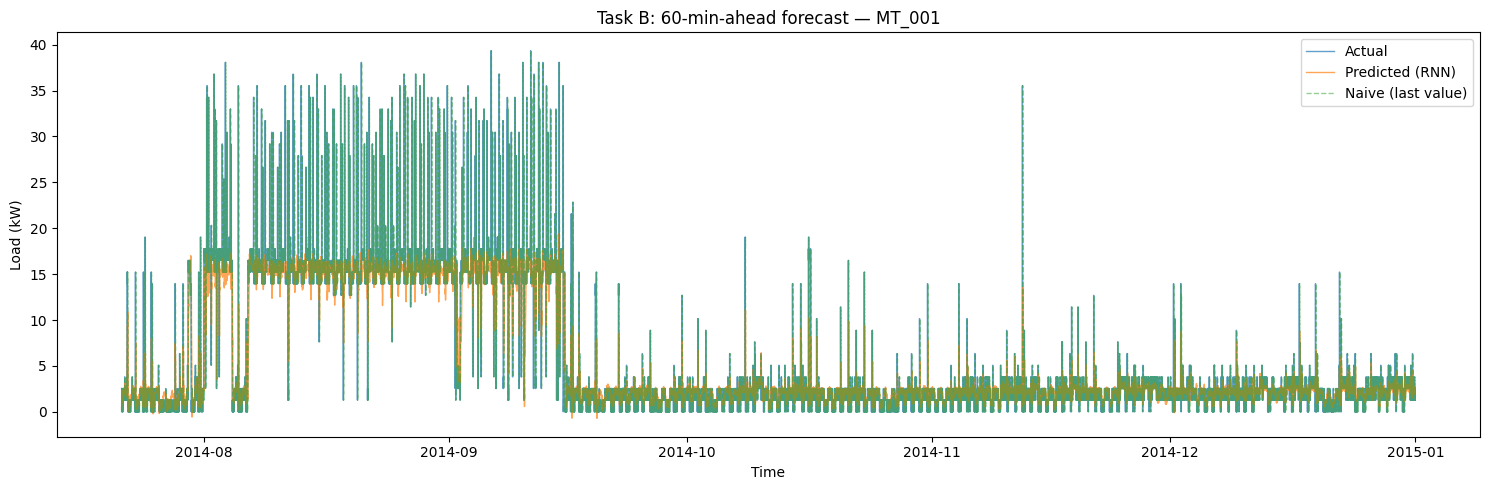

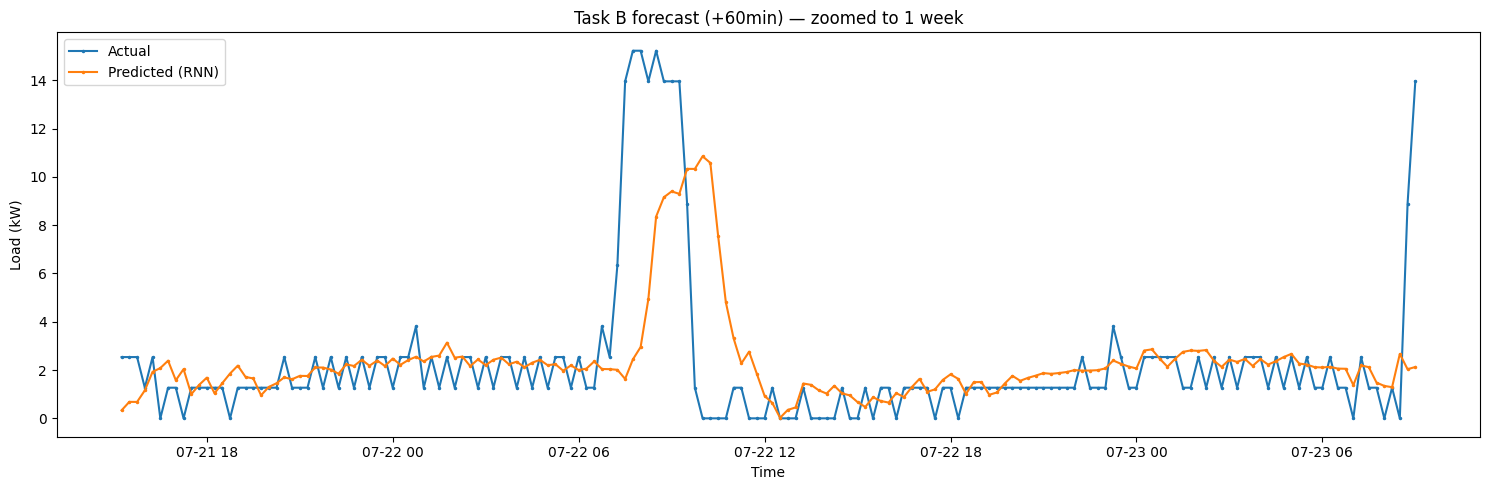

In [42]:
import json
# --- per-horizon timestamps (correction: offset shifts by k per column) ---
n_samples = y_true_kw.shape[0]
horizon_labels = ["+15 min", "+30 min", "+45 min", "+60 min"]
timestamps_per_step = [
    test["timestamp"].values[96 + k : 96 + k + n_samples] for k in range(4)
]

# --- headline plot: +60min ahead (last horizon step), full test set ---
headline_step = 3  # +60 min
ts_headline = timestamps_per_step[headline_step]

plt.figure(figsize=(15, 5))
plt.plot(ts_headline, y_true_kw[:, headline_step], label="Actual", alpha=0.7, linewidth=1)
plt.plot(ts_headline, y_pred_kw[:, headline_step], label="Predicted (RNN)", alpha=0.7, linewidth=1)
plt.plot(ts_headline, naive_pred_kw[:, headline_step], label="Naive (last value)", alpha=0.5, linewidth=1, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.title("Task B: 60-min-ahead forecast — MT_001")
plt.legend()
plt.tight_layout()
plt.show()

# --- zoomed plot: ~1 week, +60min headline ---
zoom_n = 168  # ~1 week at hourly-step granularity (168 samples, not 672 — see note below)
plt.figure(figsize=(15, 5))
plt.plot(ts_headline[:zoom_n], y_true_kw[:zoom_n, headline_step], label="Actual", marker=".", markersize=3)
plt.plot(ts_headline[:zoom_n], y_pred_kw[:zoom_n, headline_step], label="Predicted (RNN)", marker=".", markersize=3)
plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.title("Task B forecast (+60min) — zoomed to 1 week")
plt.legend()
plt.tight_layout()
plt.show()


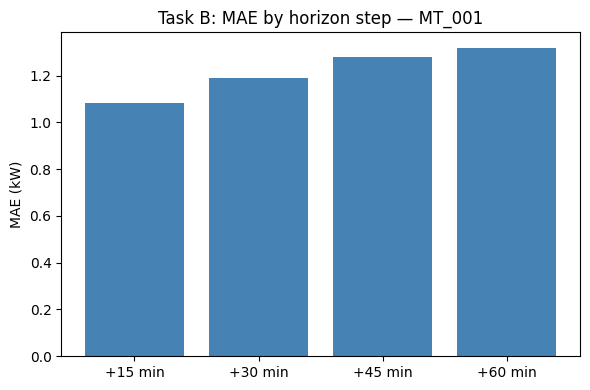

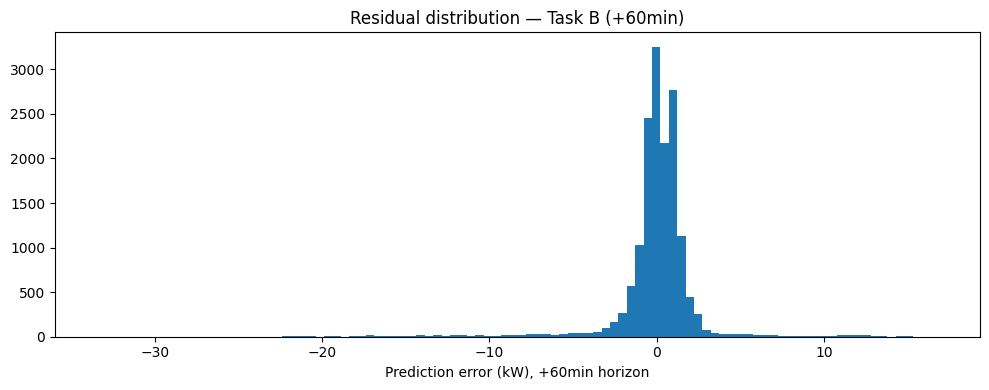

hour
9     2.807311
10    2.456010
7     2.011360
15    1.861947
14    1.806473
8     1.740550
11    1.715750
18    1.594139
12    1.307283
13    1.176399
19    1.124752
17    1.090138
16    1.084639
23    1.058235
21    1.000971
6     0.974159
0     0.962774
22    0.958114
1     0.945246
2     0.850605
5     0.817385
20    0.815811
3     0.767382
4     0.733398
Name: abs_error, dtype: float32


In [43]:

# --- NEW: per-horizon MAE comparison (replaces the messy 4-line overlay Task A's code would've produced) ---
step_maes = [np.mean(np.abs(y_pred_kw[:, k] - y_true_kw[:, k])) for k in range(4)]
plt.figure(figsize=(6, 4))
plt.bar(horizon_labels, step_maes, color="steelblue")
plt.ylabel("MAE (kW)")
plt.title("Task B: MAE by horizon step — MT_001")
plt.tight_layout()
plt.show()

# --- residual distribution, headline step only ---
residuals_headline = (y_pred_kw[:, headline_step] - y_true_kw[:, headline_step]).flatten()
plt.figure(figsize=(10, 4))
plt.hist(residuals_headline, bins=100)
plt.xlabel("Prediction error (kW), +60min horizon")
plt.title("Residual distribution — Task B (+60min)")
plt.tight_layout()
plt.show()

# --- error by hour of day, headline step, correctly aligned timestamps ---
test_hours_headline = test["hour_of_day"].values[96 + headline_step : 96 + headline_step + n_samples]
error_by_hour = pd.DataFrame({"hour": test_hours_headline, "abs_error": np.abs(residuals_headline)})
print(error_by_hour.groupby("hour")["abs_error"].mean().sort_values(ascending=False))


In [44]:
# --- results dict: per-horizon breakdown included ---
results = {
    "client": "MT_001",
    "task": "B",
    "horizon_steps": 4,
    "mae_kw": float(mae),
    "rmse_kw": float(rmse),
    "mape_masked_pct": float(mape_masked),
    "naive_mae_kw": float(naive_mae),
    "naive_rmse_kw": float(naive_rmse),
    "mae_improvement_pct": float(mae_improve),
    "rmse_improvement_pct": float(rmse_improve),
    "per_horizon_mae_kw": {horizon_labels[k]: float(step_maes[k]) for k in range(4)},
}
print(results)

results_path = "/content/drive/MyDrive/tfrecords/results_log.jsonl"
with open(results_path, "a") as f:
    f.write(json.dumps(results) + "\n")

{'client': 'MT_001', 'task': 'B', 'horizon_steps': 4, 'mae_kw': 1.2169233560562134, 'rmse_kw': 2.524653911590576, 'mape_masked_pct': 34.921024322509766, 'naive_mae_kw': 1.3294367790222168, 'naive_rmse_kw': 3.2371394634246826, 'mae_improvement_pct': 8.463239669799805, 'rmse_improvement_pct': 22.009723663330078, 'per_horizon_mae_kw': {'+15 min': 1.0831482410430908, '+30 min': 1.1880472898483276, '+45 min': 1.2776814699172974, '+60 min': 1.3188163042068481}}


### **Stacked LSTM**

In [32]:
def evaluate_model_full(model, test_ds, load_scaler, feature_cols, test_df,
                         model_name: str, task_name: str,
                         client_id: str = "MT_001",
                         results_path: str = "/content/drive/MyDrive/tfrecords/results_log.jsonl"):
    """
    Predicts on test_ds, inverse-transforms to kW, computes naive baseline,
    prints/logs metrics. Works for any output_len (1, 4, 96, ...).
    Returns (results_dict, y_pred_kw, y_true_kw).
    """
    y_pred_scaled = model.predict(test_ds)
    y_true_scaled = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

    if y_pred_scaled.ndim == 1:
        y_pred_scaled = y_pred_scaled.reshape(-1, 1)
    if y_true_scaled.ndim == 1:
        y_true_scaled = y_true_scaled.reshape(-1, 1)

    n_samples, output_len = y_pred_scaled.shape

    y_pred_kw = load_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(n_samples, output_len)
    y_true_kw = load_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(n_samples, output_len)

    # --- naive baseline: repeat last observed value across the horizon ---
    X_test_list = [x_batch.numpy() for x_batch, _ in test_ds]
    X_test_arr = np.concatenate(X_test_list, axis=0)
    load_scaled_idx = feature_cols.index("load_scaled")
    last_val_scaled = X_test_arr[:, -1, load_scaled_idx].reshape(-1, 1)
    naive_pred_scaled = np.tile(last_val_scaled, (1, output_len))
    naive_pred_kw = load_scaler.inverse_transform(naive_pred_scaled.reshape(-1, 1)).reshape(n_samples, output_len)

    mae = np.mean(np.abs(y_pred_kw - y_true_kw))
    rmse = np.sqrt(np.mean((y_pred_kw - y_true_kw) ** 2))
    naive_mae = np.mean(np.abs(naive_pred_kw - y_true_kw))
    naive_rmse = np.sqrt(np.mean((naive_pred_kw - y_true_kw) ** 2))

    epsilon = 1e-3
    mask = np.abs(y_true_kw) > 0.1
    mape_masked = np.mean(
        np.abs((y_true_kw[mask] - y_pred_kw[mask]) / np.clip(np.abs(y_true_kw[mask]), epsilon, None))
    ) * 100

    mae_improvement_pct = (1 - mae / naive_mae) * 100
    rmse_improvement_pct = (1 - rmse / naive_rmse) * 100

    print("=" * 50)
    print(f"{model_name.upper()} — Task {task_name}")
    print("=" * 50)
    print(f"MAE:  {mae:.4f} kW   (naive: {naive_mae:.4f} kW)")
    print(f"RMSE: {rmse:.4f} kW   (naive: {naive_rmse:.4f} kW)")
    print(f"MAPE (masked, |y|>0.1kW): {mape_masked:.2f}%")
    print(f"MAE improvement vs naive:  {mae_improvement_pct:.1f}%")
    print(f"RMSE improvement vs naive: {rmse_improvement_pct:.1f}%")

    results = {
        "client": client_id,
        "model": model_name,
        "task": task_name,
        "horizon_steps": output_len,
        "mae_kw": float(mae),
        "rmse_kw": float(rmse),
        "mape_masked_pct": float(mape_masked),
        "naive_mae_kw": float(naive_mae),
        "naive_rmse_kw": float(naive_rmse),
        "mae_improvement_pct": float(mae_improvement_pct),
        "rmse_improvement_pct": float(rmse_improvement_pct),
    }

    if output_len > 1:
        step_maes = [np.mean(np.abs(y_pred_kw[:, k] - y_true_kw[:, k])) for k in range(output_len)]
        results["per_horizon_mae_kw"] = {f"step_{k+1}": float(step_maes[k]) for k in range(output_len)}
        for k in range(output_len):
            print(f"  step {k+1} — MAE: {step_maes[k]:.4f} kW")

    print(results)

    with open(results_path, "a") as f:
        f.write(json.dumps(results) + "\n")

    return results, y_pred_kw, y_true_kw

In [33]:
def build_stacked_lstm_model(input_len: int, n_features: int, output_len: int,
                               units_1: int = 64, units_2: int = 32, dropout: float = 0.2):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.LSTM(units_1, return_sequences=True),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.LSTM(units_2, return_sequences=False),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [47]:
# ---------- Stacked LSTM ----------
model_B_lstm_stacked = build_stacked_lstm_model(96, n_features, output_len=4)
model_B_lstm_stacked.summary()
callbacks_B_lstm_stacked, log_dir_B_lstm_stacked = make_callbacks("task_B_lstm_stacked")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,700 (123.83 KB)

 Trainable params: 31,700 (123.83 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history_B_lstm_stacked = model_B_lstm_stacked.fit(
    train_ds_B, validation_data=val_ds_B, epochs=1000,
    callbacks=callbacks_B_lstm_stacked, verbose=1,
)


Epoch 1/1000
   1149/Unknown 31s 19ms/step - loss: 0.5792 - mae: 0.4795

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.16467, saving model to /content/drive/MyDrive/logs/task_B_lstm_stacked/20260831-205140/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_B_lstm_stacked/20260831-205140/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 0.3186 - mae: 0.3139 - val_loss: 0.1647 - val_mae: 0.2051 - learning_rate: 0.0010
Epoch 2/1000
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4198 - mae: 0.3789
Epoch 2: val_loss improved from 0.16467 to 0.15378, saving model to /content/drive/MyDrive/logs/task_B_lstm_stacked/20260831-205140/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_B_lstm_stacked/20260831-205140/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 0.2546 - mae: 0.2680 - val_loss: 0.1538 - val_mae: 0.1928 - learning_rate: 0.0010
Epoch 3/1000
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3966 - mae: 0.3626
Epoch 3: val_loss did not impr

In [36]:
import tensorflow as tf

# Path to the best saved model
model_path = "/content/drive/MyDrive/logs/task_B_lstm_stacked/20260831-205140/best_model.keras"

# Load the trained model
model_B_lstm_stacked = tf.keras.models.load_model(model_path)

# Check model
# model_B_lstm_stacked.summary()

In [38]:
import json
results_lstm_stacked, y_pred_lstm_stacked, y_true_lstm_stacked = evaluate_model_full(
    model_B_lstm_stacked, test_ds_B, load_scaler, feature_cols, test,
    model_name="lstm_stacked", task_name="B"
)


246/246 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


LSTM_STACKED — Task B
MAE:  1.2599 kW   (naive: 1.3294 kW)
RMSE: 2.6087 kW   (naive: 3.2371 kW)
MAPE (masked, |y|>0.1kW): 32.14%
MAE improvement vs naive:  5.2%
RMSE improvement vs naive: 19.4%
  step 1 — MAE: 1.1061 kW
  step 2 — MAE: 1.1821 kW
  step 3 — MAE: 1.3611 kW
  step 4 — MAE: 1.3904 kW
{'client': 'MT_001', 'model': 'lstm_stacked', 'task': 'B', 'horizon_steps': 4, 'mae_kw': 1.2599108219146729, 'rmse_kw': 2.6086578369140625, 'mape_masked_pct': 32.140445709228516, 'naive_mae_kw': 1.3294367790222168, 'naive_rmse_kw': 3.2371394634246826, 'mae_improvement_pct': 5.229729652404785, 'rmse_improvement_pct': 19.414722442626953, 'per_horizon_mae_kw': {'step_1': 1.1061196327209473, 'step_2': 1.1820542812347412, 'step_3': 1.3610600233078003, 'step_4': 1.3904095888137817}}


In [39]:
def visualize_forecast(y_true_kw, y_pred_kw, test_df, model_name: str, task_name: str,
                        input_len: int = 96, headline_step: int = -1, zoom_n: int = 168,
                        test_ds=None, load_scaler=None, feature_cols=None):
    """
    Generic forecast visualization — works for output_len=1 (Task A) or output_len>1 (Task B/C).

    y_true_kw, y_pred_kw : arrays of shape (n_samples,) or (n_samples, output_len)
    test_df              : the test split DataFrame with a "timestamp" and "hour_of_day" column
    headline_step        : which horizon column to use for the main line plots (-1 = last step,
                            e.g. +60min for Task B). Ignored if output_len == 1.
    test_ds/load_scaler/feature_cols : optional — if all three given, naive baseline is
                            recomputed and overlaid; otherwise naive is skipped.
    """
    y_true_kw = np.atleast_2d(y_true_kw)
    y_pred_kw = np.atleast_2d(y_pred_kw)
    if y_true_kw.shape[0] == 1 and y_true_kw.shape[1] != 1:
        y_true_kw = y_true_kw.T
        y_pred_kw = y_pred_kw.T

    n_samples, output_len = y_true_kw.shape
    step = headline_step % output_len  # resolves -1 to last valid index
    horizon_labels = [f"+{(k+1)*15} min" for k in range(output_len)]

    # --- naive baseline (optional recompute) ---
    naive_pred_kw = None
    if test_ds is not None and load_scaler is not None and feature_cols is not None:
        X_test_arr = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
        load_scaled_idx = feature_cols.index("load_scaled")
        last_val_scaled = X_test_arr[:, -1, load_scaled_idx].reshape(-1, 1)
        naive_pred_scaled = np.tile(last_val_scaled, (1, output_len))
        naive_pred_kw = load_scaler.inverse_transform(naive_pred_scaled.reshape(-1, 1)).reshape(n_samples, output_len)

    # --- per-step aligned timestamps ---
    timestamps_per_step = [test_df["timestamp"].values[input_len + k: input_len + k + n_samples] for k in range(output_len)]
    ts_headline = timestamps_per_step[step]

    # --- headline plot: full test set ---
    plt.figure(figsize=(15, 5))
    plt.plot(ts_headline, y_true_kw[:, step], label="Actual", alpha=0.7, linewidth=1)
    plt.plot(ts_headline, y_pred_kw[:, step], label=f"Predicted ({model_name})", alpha=0.7, linewidth=1)
    if naive_pred_kw is not None:
        plt.plot(ts_headline, naive_pred_kw[:, step], label="Naive (last value)", alpha=0.5, linewidth=1, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Load (kW)")
    plt.title(f"Task {task_name}: {horizon_labels[step]}-ahead forecast — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- zoomed plot ---
    plt.figure(figsize=(15, 5))
    plt.plot(ts_headline[:zoom_n], y_true_kw[:zoom_n, step], label="Actual", marker=".", markersize=3)
    plt.plot(ts_headline[:zoom_n], y_pred_kw[:zoom_n, step], label=f"Predicted ({model_name})", marker=".", markersize=3)
    plt.xlabel("Time")
    plt.ylabel("Load (kW)")
    plt.title(f"Task {task_name} forecast ({horizon_labels[step]}) — zoomed — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- per-horizon MAE bar (only meaningful if output_len > 1) ---
    if output_len > 1:
        step_maes = [np.mean(np.abs(y_pred_kw[:, k] - y_true_kw[:, k])) for k in range(output_len)]
        plt.figure(figsize=(6, 4))
        plt.bar(horizon_labels, step_maes, color="steelblue")
        plt.ylabel("MAE (kW)")
        plt.title(f"Task {task_name}: MAE by horizon step — {model_name}")
        plt.tight_layout()
        plt.show()

    # --- residual distribution (headline step) ---
    residuals = (y_pred_kw[:, step] - y_true_kw[:, step]).flatten()
    plt.figure(figsize=(10, 4))
    plt.hist(residuals, bins=100)
    plt.xlabel(f"Prediction error (kW), {horizon_labels[step]} horizon")
    plt.title(f"Residual distribution — Task {task_name} ({horizon_labels[step]}) — {model_name}")
    plt.tight_layout()
    plt.show()

    # --- error by hour of day (headline step) ---
    test_hours = test_df["hour_of_day"].values[input_len + step: input_len + step + n_samples]
    error_by_hour = pd.DataFrame({"hour": test_hours, "abs_error": np.abs(residuals)})
    print(f"\n{model_name} — mean absolute error by hour of day ({horizon_labels[step]}):")
    print(error_by_hour.groupby("hour")["abs_error"].mean().sort_values(ascending=False))



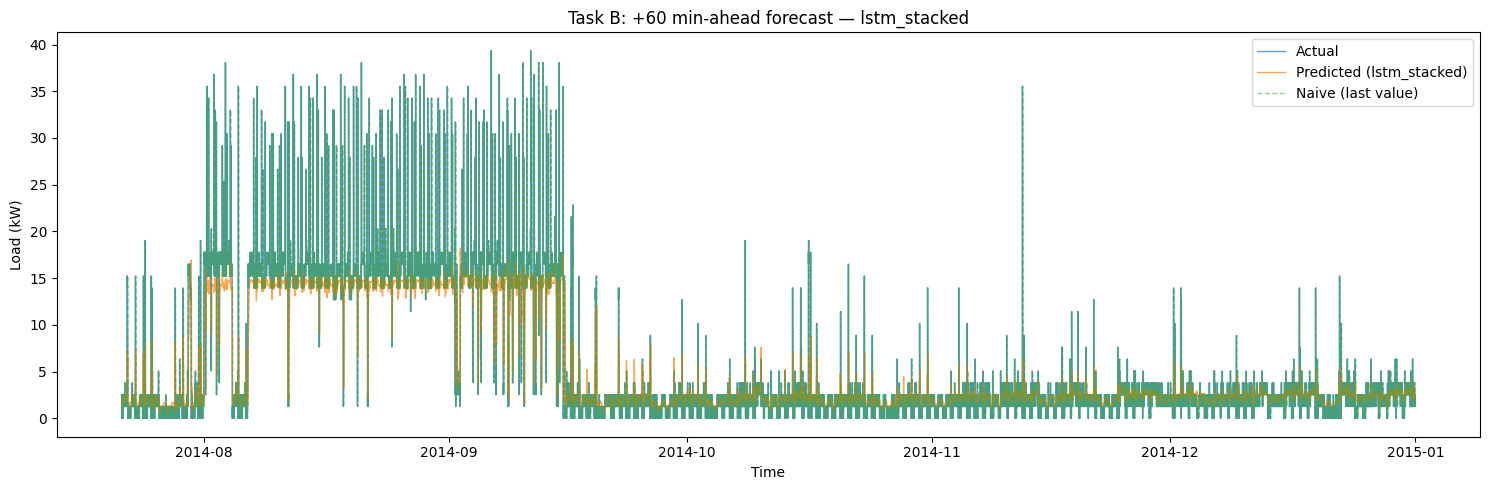

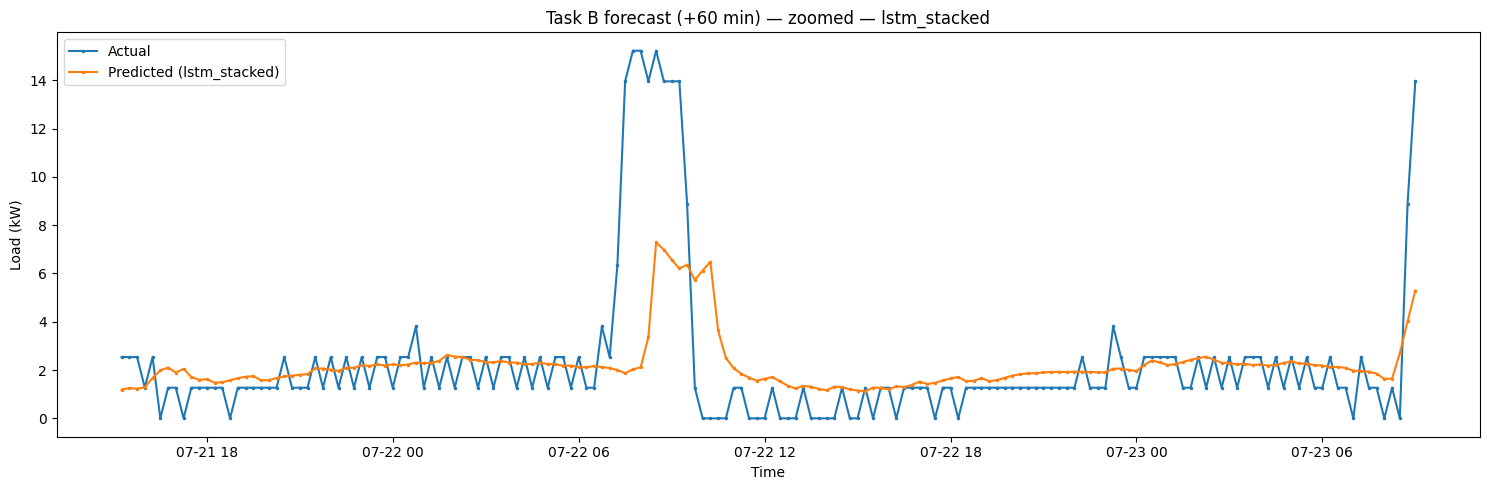

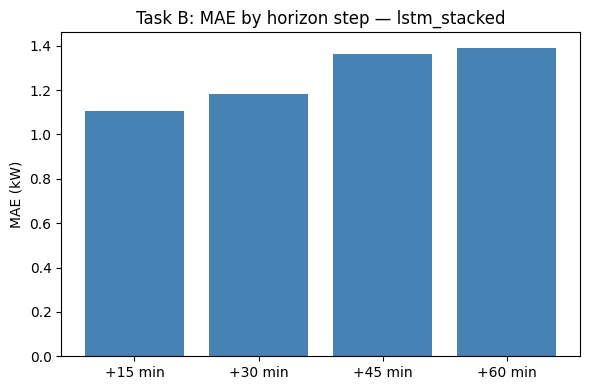

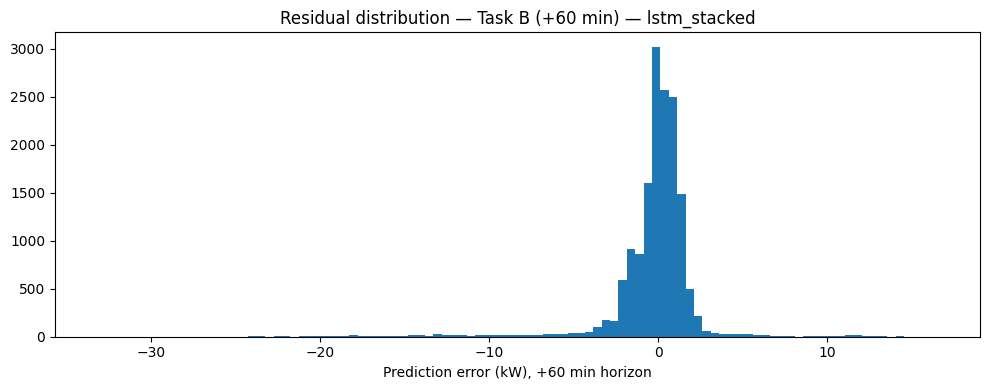


lstm_stacked — mean absolute error by hour of day (+60 min):
hour
9     2.774997
10    2.125149
7     2.112121
14    1.857034
8     1.729034
18    1.710379
15    1.690909
11    1.577585
23    1.265653
12    1.243956
19    1.230812
13    1.197318
21    1.179840
6     1.162569
22    1.157378
16    1.138720
17    1.132137
1     1.113633
0     1.107678
2     1.044588
5     1.001592
3     0.974096
4     0.943221
20    0.907080
Name: abs_error, dtype: float32


In [40]:

visualize_forecast(y_true_lstm_stacked, y_pred_lstm_stacked, test,
                    model_name="lstm_stacked", task_name="B",
                    test_ds=test_ds_B, load_scaler=load_scaler, feature_cols=feature_cols)

### **GRU**

In [53]:
def build_gru_model(input_len: int, n_features: int, output_len: int, units: int = 32):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.GRU(units, return_sequences=False),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [54]:
# ---------- GRU ----------
model_B_gru = build_gru_model(96, n_features, output_len=4)
model_B_gru.summary()
callbacks_B_gru, log_dir_B_gru = make_callbacks("task_B_GRU")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,628 (18.08 KB)

 Trainable params: 4,628 (18.08 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history_B_gru = model_B_gru.fit(
    train_ds_B, validation_data=val_ds_B, epochs=1000,
    callbacks=callbacks_B_gru, verbose=1,
)

Epoch 1/1000
   1150/Unknown 28s 22ms/step - loss: 0.5644 - mae: 0.4633

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.16179, saving model to /content/drive/MyDrive/logs/task_B_GRU/20260831-210356/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_B_GRU/20260831-210356/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - loss: 0.2953 - mae: 0.2894 - val_loss: 0.1618 - val_mae: 0.2023 - learning_rate: 0.0010
Epoch 2/1000
1148/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4130 - mae: 0.3650
Epoch 2: val_loss improved from 0.16179 to 0.15803, saving model to /content/drive/MyDrive/logs/task_B_GRU/20260831-210356/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_B_GRU/20260831-210356/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.2485 - mae: 0.2558 - val_loss: 0.1580 - val_mae: 0.1985 - learning_rate: 0.0010
Epoch 3/1000
1149/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3966 - mae: 0.3548
Epoch 3: val_loss improved from 0.15803 to 0.15640, saving model t

In [56]:
results_gru, y_pred_gru, y_true_gru = evaluate_model_full(
    model_B_gru, test_ds_B, load_scaler, feature_cols, test,
    model_name="gru", task_name="B"
)

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
GRU — Task B
MAE:  1.2293 kW   (naive: 1.3294 kW)
RMSE: 2.5295 kW   (naive: 3.2371 kW)
MAPE (masked, |y|>0.1kW): 33.53%
MAE improvement vs naive:  7.5%
RMSE improvement vs naive: 21.9%
  step 1 — MAE: 1.0512 kW
  step 2 — MAE: 1.2007 kW
  step 3 — MAE: 1.2988 kW
  step 4 — MAE: 1.3665 kW
{'client': 'MT_001', 'model': 'gru', 'task': 'B', 'horizon_steps': 4, 'mae_kw': 1.229286551475525, 'rmse_kw': 2.5294675827026367, 'mape_masked_pct': 33.526180267333984, 'naive_mae_kw': 1.3294367790222168, 'naive_rmse_kw': 3.2371394634246826, 'mae_improvement_pct': 7.533282279968262, 'rmse_improvement_pct': 21.86102294921875, 'per_horizon_mae_kw': {'step_1': 1.0511966943740845, 'step_2': 1.200661540031433, 'step_3': 1.2987775802612305, 'step_4': 1.3665103912353516}}


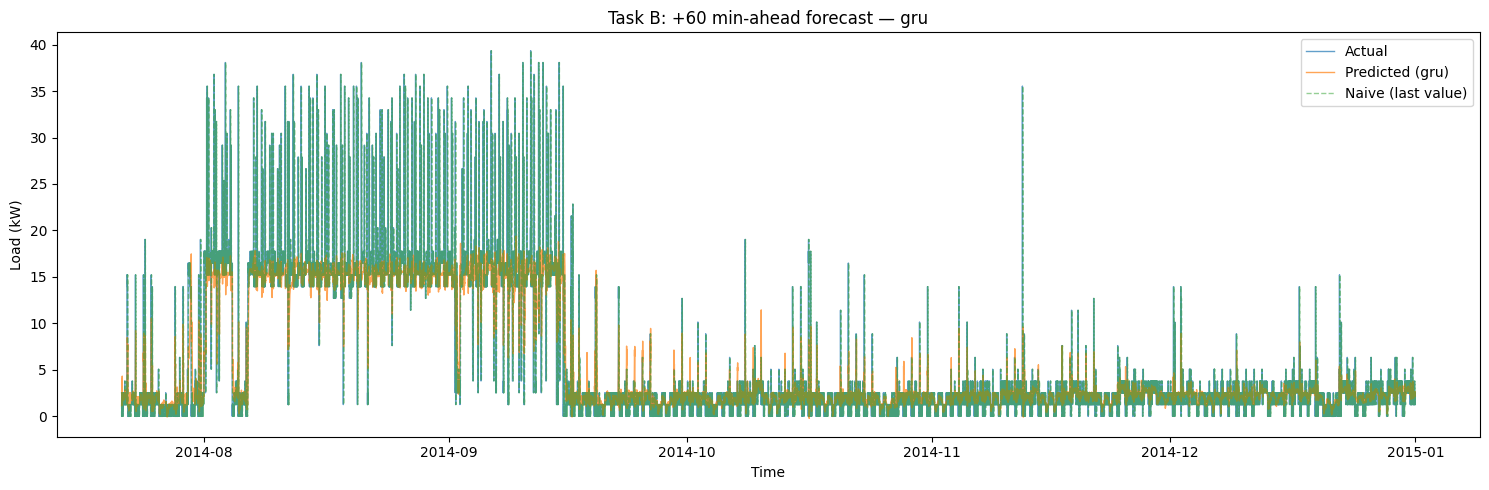

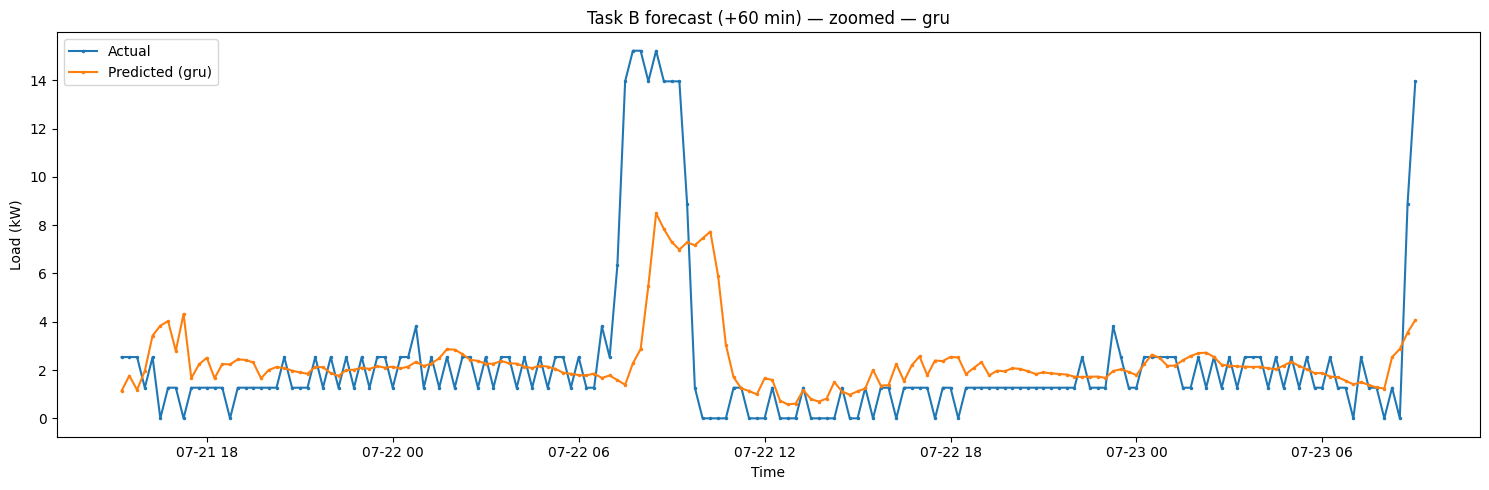

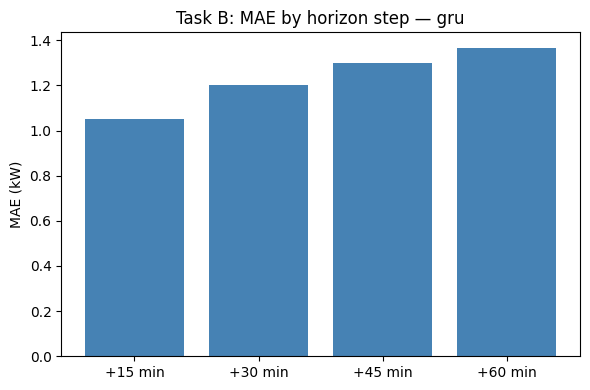

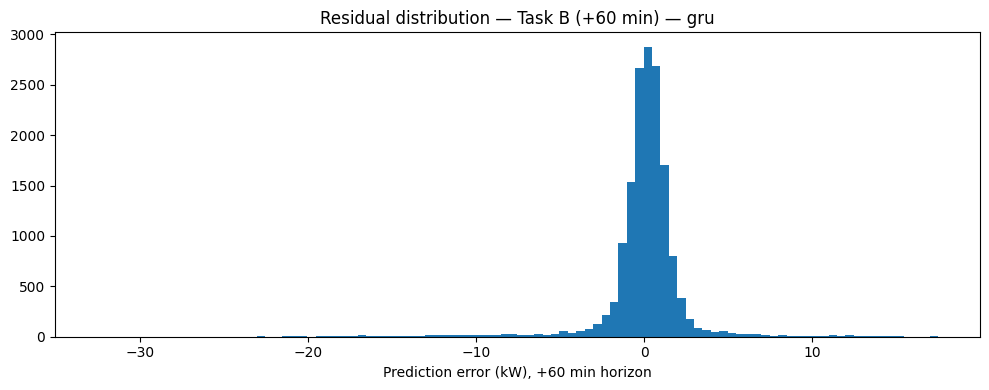


gru — mean absolute error by hour of day (+60 min):
hour
9     2.934891
10    2.571676
7     1.917882
14    1.831266
15    1.763021
18    1.690832
8     1.658442
11    1.626306
17    1.363922
16    1.282572
12    1.256483
19    1.203491
13    1.169283
21    1.098397
23    1.062646
22    1.005863
6     0.992534
1     0.967973
0     0.950011
2     0.949528
3     0.907619
4     0.870997
20    0.870684
5     0.857051
Name: abs_error, dtype: float32


In [57]:
visualize_forecast(y_true_gru, y_pred_gru, test,
                    model_name="gru", task_name="B",
                    test_ds=test_ds_B, load_scaler=load_scaler, feature_cols=feature_cols)


## **Transformer**

In [43]:
class PositionalEncoding(tf.keras.layers.Layer):

  def __init__(self, seq_len, d_model, **kwargs):
    super().__init__(**kwargs)
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    self.pe = tf.constant(pe, dtype=tf.float32)

  def call(self, x):
    return x + self.pe


def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout=0.1):
  attn = tf.keras.layers.MultiHeadAttention(
      num_heads=num_heads, key_dim=d_model // num_heads
  )(x, x)
  attn = tf.keras.layers.Dropout(dropout)(attn)
  x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)

  ff = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
  ff = tf.keras.layers.Dense(d_model)(ff)
  ff = tf.keras.layers.Dropout(dropout)(ff)
  x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + ff)
  return x


def build_transformer_model(
    input_len: int,
    n_features: int,
    output_len: int,
    d_model: int = 32,
    num_heads: int = 4,
    ff_dim: int = 64,
    num_blocks: int = 2,
    dropout: float = 0.1,
):
  inputs = tf.keras.layers.Input(shape=(input_len, n_features))
  x = tf.keras.layers.Dense(d_model)(inputs)
  x = PositionalEncoding(input_len, d_model)(x)

  for _ in range(num_blocks):
    x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout)

  x = tf.keras.layers.GlobalAveragePooling1D()(x)
  x = tf.keras.layers.Dense(16, activation="relu")(x)
  outputs = tf.keras.layers.Dense(output_len)(x)

  model = tf.keras.Model(inputs, outputs)
  model.compile(optimizer="adam", loss="mse", metrics=["mae"])
  return model

In [44]:
# ---------- Transformer ----------
model_B_transformer = build_transformer_model(input_len=96, n_features=n_features, output_len=4)
model_B_transformer.summary()
callbacks_B_trans, log_dir_B_trans = make_callbacks("task_B_transformer")


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96, 32)    │        288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 96, 32)    │          0 │ dense[0][0]       │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 32)    │      4,224 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 32)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 96, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 96, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96, 32)    │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 96, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 96, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 96, 32)    │      2,080 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 96, 32)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat

 Total params: 17,972 (70.20 KB)

 Trainable params: 17,972 (70.20 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history_B_transformer = model_B_transformer.fit(
    train_ds_B, validation_data=val_ds_B, epochs=1000,
    callbacks=callbacks_B_trans, verbose=1,
)

Epoch 1/1000
   1150/Unknown 295s 242ms/step - loss: 0.5742 - mae: 0.4912

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.16024, saving model to /content/drive/MyDrive/logs/task_B_transformer/20260831-213105/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_B_transformer/20260831-213105/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 315s 259ms/step - loss: 0.3106 - mae: 0.3069 - val_loss: 0.1602 - val_mae: 0.2075 - learning_rate: 0.0010
Epoch 2/1000
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 0.4169 - mae: 0.3690
Epoch 2: val_loss improved from 0.16024 to 0.15606, saving model to /content/drive/MyDrive/logs/task_B_transformer/20260831-213105/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_B_transformer/20260831-213105/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 321s 262ms/step - loss: 0.2508 - mae: 0.2605 - val_loss: 0.1561 - val_mae: 0.2036 - learning_rate: 0.0010
Epoch 3/1000
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 0.4019 - mae: 0.3609
Epoch 3: val_loss improved f

In [46]:
results_trans, y_pred_trans, y_true_trans = evaluate_model_full(
    model=model_B_transformer, test_ds=test_ds_B,
    load_scaler=load_scaler, feature_cols=feature_cols, test_df=test,
    model_name="transformer", task_name="B",
)

246/246 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step
TRANSFORMER — Task B
MAE:  1.2175 kW   (naive: 1.3294 kW)
RMSE: 2.5314 kW   (naive: 3.2371 kW)
MAPE (masked, |y|>0.1kW): 35.56%
MAE improvement vs naive:  8.4%
RMSE improvement vs naive: 21.8%
  step 1 — MAE: 1.0593 kW
  step 2 — MAE: 1.2032 kW
  step 3 — MAE: 1.2894 kW
  step 4 — MAE: 1.3180 kW
{'client': 'MT_001', 'model': 'transformer', 'task': 'B', 'horizon_steps': 4, 'mae_kw': 1.2174738645553589, 'rmse_kw': 2.5314061641693115, 'mape_masked_pct': 35.557334899902344, 'naive_mae_kw': 1.3294367790222168, 'naive_rmse_kw': 3.2371394634246826, 'mae_improvement_pct': 8.421832084655762, 'rmse_improvement_pct': 21.801137924194336, 'per_horizon_mae_kw': {'step_1': 1.0592581033706665, 'step_2': 1.20320463180542, 'step_3': 1.2893842458724976, 'step_4': 1.3180480003356934}}


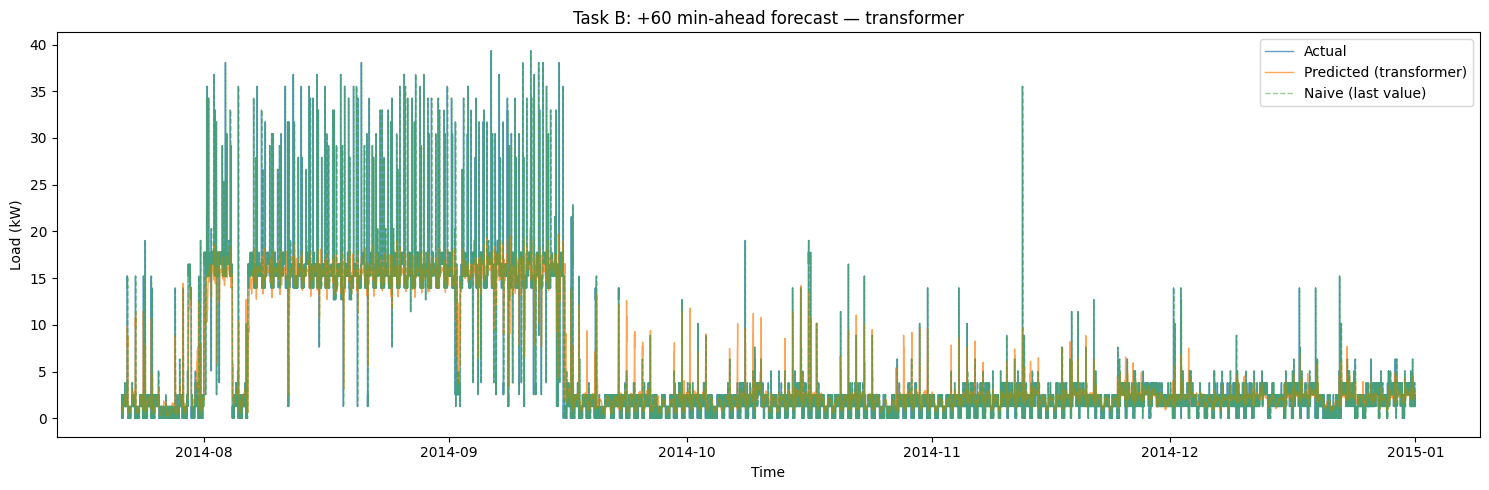

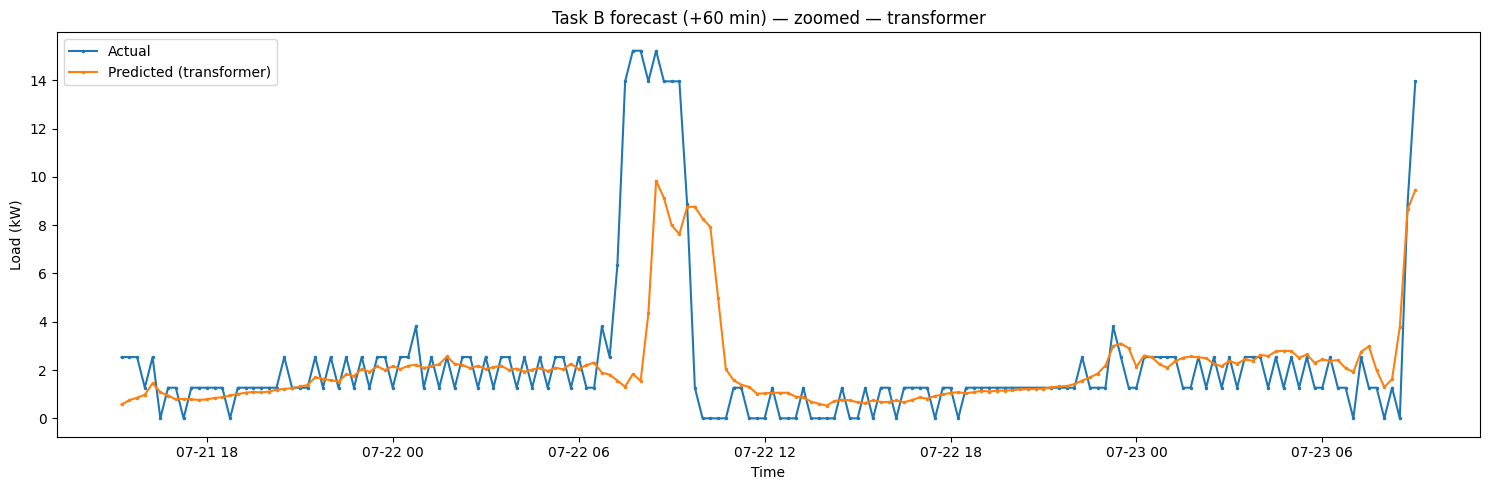

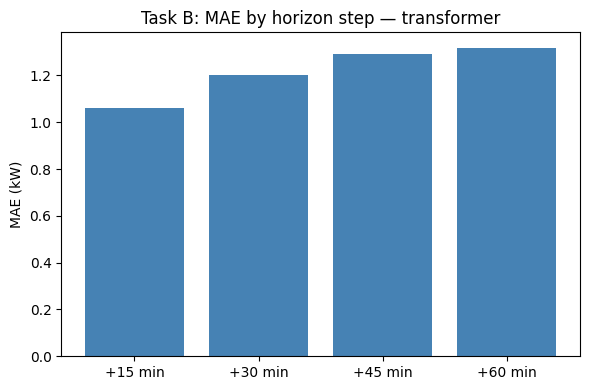

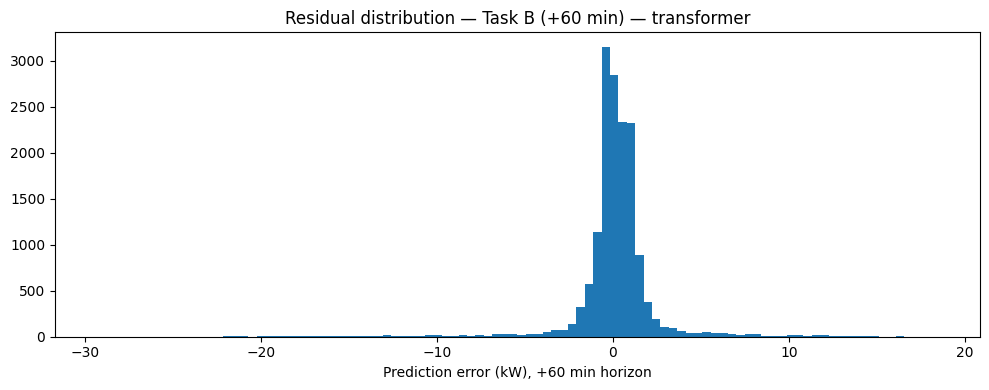


transformer — mean absolute error by hour of day (+60 min):
hour
9     3.360598
10    3.027562
7     1.899071
14    1.748747
15    1.711082
8     1.592011
11    1.591079
18    1.569607
17    1.144605
19    1.118491
12    1.092619
16    1.064783
21    1.039127
13    0.996257
6     0.985779
0     0.956481
22    0.955572
23    0.954345
1     0.910351
2     0.850078
5     0.835664
20    0.798353
3     0.761226
4     0.680069
Name: abs_error, dtype: float32


In [47]:
visualize_forecast(y_true_trans, y_pred_trans, test,
                    model_name="transformer", task_name="B",
                    test_ds=test_ds_B, load_scaler=load_scaler, feature_cols=feature_cols)